In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
warnings.simplefilter(action="ignore", category=FutureWarning)

**Section 1: Data Cleaning and Preparation**

Data Quality Assessment: Inspect the dataset for missing values, duplicates, or inconsistent data types.
Feature Engineering: Create the following columns: “Month-Year” (e.g., August 2024) from the “DATE” column. 

In [2]:
def wrangle(filepath):
    #Drop Unwanted rows
    df=pd.read_csv(filepath)
    df=df.drop_duplicates()
    #Rename columns
    df = df.rename(columns={
    'DATE': 'DATE',
    'ANONYMIZED CATEGORY': 'ANONYMIZED_CATEGORY',
    'ANONYMIZED PRODUCT': 'ANONYMIZED_PRODUCT',
    'ANONYMIZED BUSINESS': 'ANONYMIZED_BUSINESS',
    'ANONYMIZED LOCATION': 'ANONYMIZED_LOCATION',
    'QUANTITY': 'QUANTITY',
    'UNIT PRICE': 'UNIT_PRICE'
    })

    #Drop rows with  null values
    df=df.dropna()
    #Change unit price column to int
    df['UNIT_PRICE']=df['UNIT_PRICE'].str.replace(',','').astype(int)
    
    #create a new Month-Year column
   # Convert to datetime using a temporary series (keeps the original DATE column safe)
    temp_datetime = pd.to_datetime(df['DATE'], format='%B %d, %Y, %I:%M %p')
    #Extract Month-Year (Output format example: "August 2024")
    df['Month-Year'] = temp_datetime.dt.strftime('%B %Y')

    return df
    

In [3]:
df=wrangle(r"C:\Users\Joe Zawadi\Downloads\Case Study Data - Read Only - case_study_data_2025-01-16T06_49_12.19881Z.csv")
df.shape

(329873, 8)

In [4]:
df.head(2)

,DATE,ANONYMIZED_CATEGORY,ANONYMIZED_PRODUCT,ANONYMIZED_BUSINESS,ANONYMIZED_LOCATION,QUANTITY,UNIT_PRICE,Month-Year
0,"August 18, 2024, 9:32 PM",Category-106,Product-21f4,Business-de42,Location-1ba8,1,850,August 2024
1,"August 18, 2024, 9:32 PM",Category-120,Product-4156,Business-de42,Location-1ba8,2,1910,August 2024


In [5]:
#Drop 'DATE' column for now
# df=df.drop(columns='DATE')
# df.head()

**Section 2: Exploratory Data Analysis**


In [6]:
#SALES OVERVIEW:
#Create a Total Value column by multiplying unit price by quantity
df['TOTAL_VALUE']=df['QUANTITY']*df['UNIT_PRICE']
#Calculate Total Quantity and Value grouped by: Anonymized Category and Anonymized Business
category_summary=df.groupby(['ANONYMIZED_CATEGORY']).agg({
    'QUANTITY':'sum',
    'TOTAL_VALUE':'sum'
}).reset_index()
business_summary=df.groupby(['ANONYMIZED_BUSINESS']).agg({
    'QUANTITY':'sum',
    'TOTAL_VALUE':'sum'
}).reset_index()

In [7]:
business_summary.head()

,ANONYMIZED_BUSINESS,QUANTITY,TOTAL_VALUE
0,Business-0000,8,10445
1,Business-0005,1,2645
2,Business-0029,26,77340
3,Business-003d,98,221761
4,Business-0072,127,225056


In [8]:
category_summary.head()

,ANONYMIZED_CATEGORY,QUANTITY,TOTAL_VALUE
0,Category-100,76824,134902751
1,Category-101,19564,35577822
2,Category-102,1786,464463
3,Category-104,1217,1557598
4,Category-105,1579,2690719


In [9]:
#CATEGORY SUMMARY BY VALUE
print("\n--- Business Summary by Value ---")
print("=" * 70)
print(business_summary.sort_values(by='TOTAL_VALUE',ascending=False).head())


--- Business Summary by Value ---
     ANONYMIZED_BUSINESS  QUANTITY  TOTAL_VALUE
2906       Business-978e     13991     28037358
4781       Business-fe7d      6743     26997121
1873       Business-6068      8214     16464195
144        Business-07de      6065     16258068
2353       Business-7a03      6318     13968451


In [10]:
#BUSINESS SUMMARY BY VALUE
print("\n--- Category Summary by Value ---")
print("=" * 70)
print(category_summary.sort_values(by='TOTAL_VALUE',ascending=False).head())


--- Category Summary by Value ---
   ANONYMIZED_CATEGORY  QUANTITY  TOTAL_VALUE
25         Category-75    151330    544658700
26         Category-76     71719    344939553
18        Category-120    169715    319178743
0         Category-100     76824    134902751
17        Category-119     68332    103454819


In [11]:
#BUSINESS SUMMARY BY QUANTITY
print("\n--- Business Summary by Quantity ---")
print("=" * 70)
print(business_summary.sort_values(by='QUANTITY',ascending=False).head())


--- Business Summary by Quantity ---
     ANONYMIZED_BUSINESS  QUANTITY  TOTAL_VALUE
2906       Business-978e     13991     28037358
1873       Business-6068      8214     16464195
4781       Business-fe7d      6743     26997121
2353       Business-7a03      6318     13968451
144        Business-07de      6065     16258068


In [12]:
#CATEGORY SUMMARY BY QUANTITY
print("\n--- Category Summary by Quantity ---")
print("=" * 70)
print(category_summary.sort_values(by='QUANTITY',ascending=False).head())


--- Category Summary by Quantity ---
   ANONYMIZED_CATEGORY  QUANTITY  TOTAL_VALUE
18        Category-120    169715    319178743
25         Category-75    151330    544658700
0         Category-100     76824    134902751
26         Category-76     71719    344939553
17        Category-119     68332    103454819


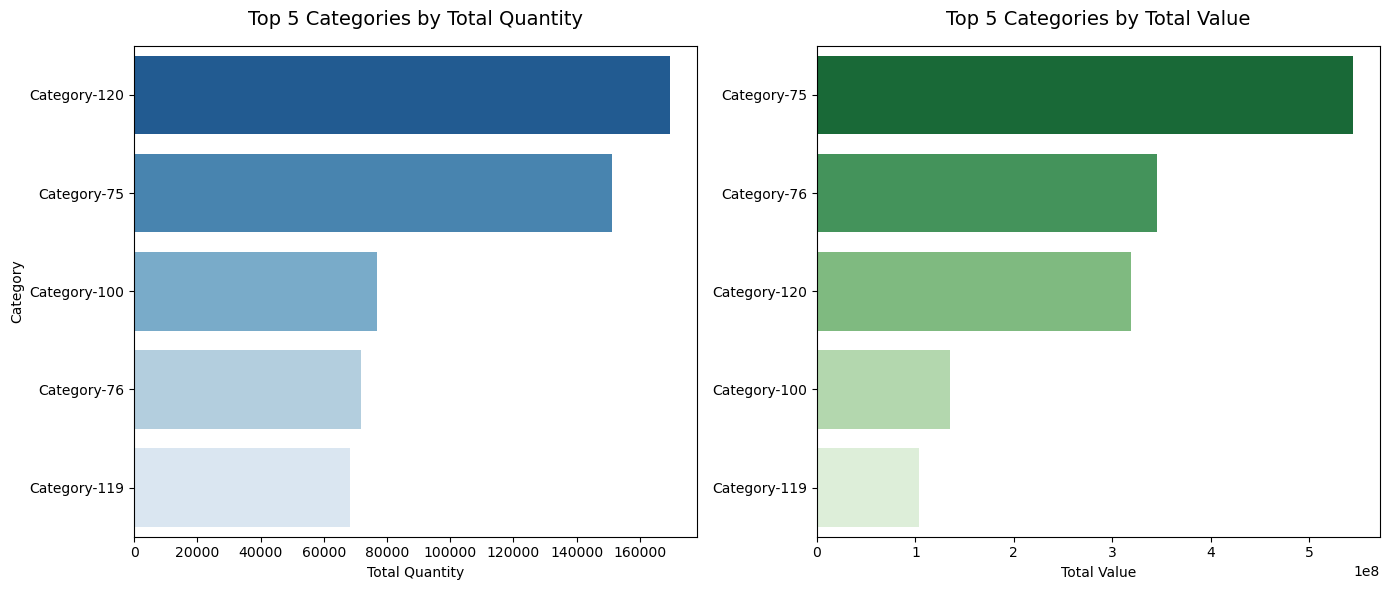

In [13]:

# 1. Get Top 5 Categories by QUANTITY
top5_quantity = category_summary.sort_values(by='QUANTITY', ascending=False).head(5)

# 2. Get Top 5 Categories by VALUE
top5_value = category_summary.sort_values(by='TOTAL_VALUE', ascending=False).head(5)

# 3. Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Top 5 by Quantity
sns.barplot(
    data=top5_quantity, 
    x='QUANTITY', 
    y='ANONYMIZED_CATEGORY', 
    ax=axes[0], 
    palette='Blues_r'
)
axes[0].set_title('Top 5 Categories by Total Quantity', fontsize=14, pad=15)
axes[0].set_xlabel('Total Quantity')
axes[0].set_ylabel('Category')

# Plot 2: Top 5 by Value
sns.barplot(
    data=top5_value, 
    x='TOTAL_VALUE', 
    y='ANONYMIZED_CATEGORY', 
    ax=axes[1], 
    palette='Greens_r'
)
axes[1].set_title('Top 5 Categories by Total Value', fontsize=14, pad=15)
axes[1].set_xlabel('Total Value')
axes[1].set_ylabel('')  # Clear y-label for the second plot to save space

# Adjust layout and display the charts
plt.tight_layout()
plt.show()


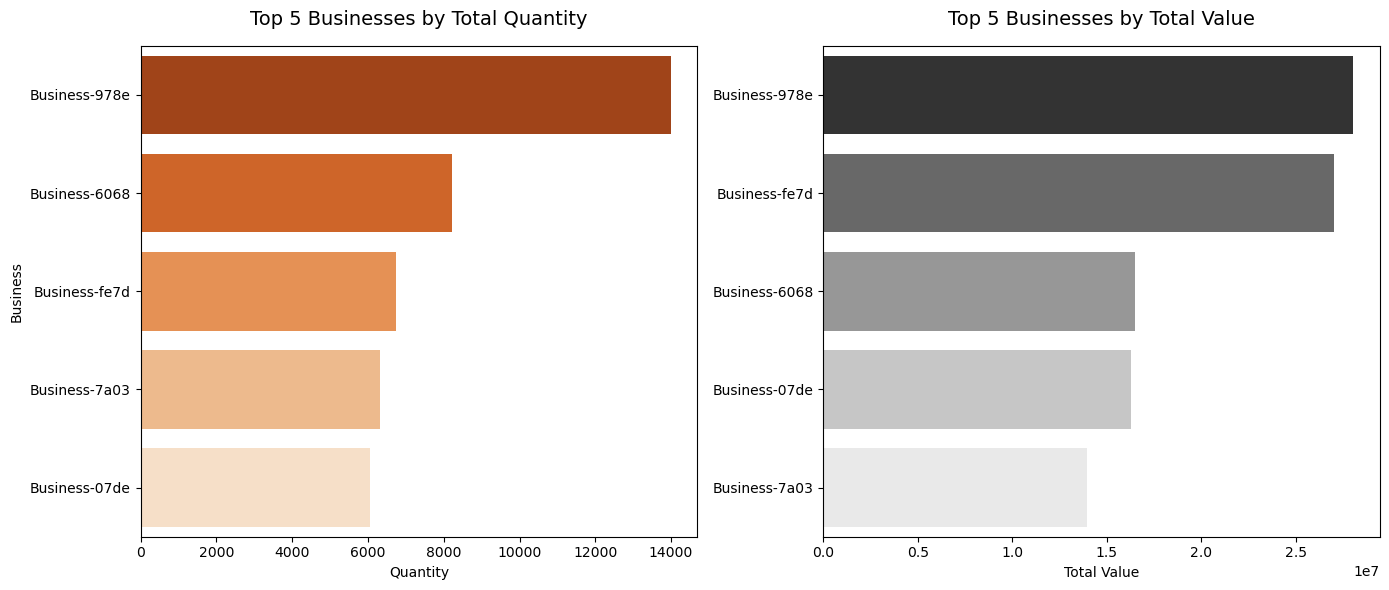

In [14]:
# 1. Get top 5 Businnesses by QUANTITY
top5_quantity=business_summary.sort_values(by='QUANTITY',ascending=False).head(5)
# 2. Get top 5 Businesses by TOTAL_VALUE
top5_value=business_summary.sort_values(by='TOTAL_VALUE',ascending=False).head(5)
#3. Set up plotting Area 1 row 2 columns
fig,axes=plt.subplots(1,2, figsize=(14,6))
# Plot 1: Top 5 by Quantity
sns.barplot(
    data=top5_quantity,
    x='QUANTITY',
    y='ANONYMIZED_BUSINESS',
    ax=axes[0],
    palette='Oranges_r'
)
axes[0].set_title('Top 5 Businesses by Total Quantity', fontsize=14, pad=15)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Business')

# Plot 2: Top 5 by Quantity
sns.barplot(
    data=top5_value,
    x='TOTAL_VALUE',
    y='ANONYMIZED_BUSINESS',
    ax=axes[1],
    palette='Greys_r'
)
axes[1].set_title('Top 5 Businesses by Total Value', fontsize=14, pad=15)
axes[1].set_xlabel('Total Value')
axes[1].set_ylabel('')  # Clear y-label for the second plot to save space

# Adjust layout and display the charts
plt.tight_layout() #fixes overlapping text and messy spacing in your plots automatically.
plt.show()

***Performance Analysis:***

In [15]:
#Identify the top 5 most frequently purchased products (based on Quantity).
product_summary=df.groupby(['ANONYMIZED_PRODUCT']).agg(
    {
        'QUANTITY': 'sum'
    }
)
print('\n Top 5 Frequently Purchased Products (based on Quantity)')
print('='* 70)
print(product_summary.sort_values(by='QUANTITY',ascending=False).head(5))


 Top 5 Frequently Purchased Products (based on Quantity
                    QUANTITY
ANONYMIZED_PRODUCT          
Product-66e0           46957
Product-e805           42602
Product-8f75           37566
Product-29ee           35940
Product-4156           28487


In [16]:
#Identify the top 5 most valuable products (based on Value).
product_summary=df.groupby(['ANONYMIZED_PRODUCT']).agg(
    {
        'TOTAL_VALUE': 'sum'
    }
)
print('\n Top 5 Frequently Purchased Products (based on Value)')
print('='* 70)
print(product_summary.sort_values(by='TOTAL_VALUE',ascending=False).head(5))


 Top 5 Frequently Purchased Products (based on Value)
                    TOTAL_VALUE
ANONYMIZED_PRODUCT             
Product-e805          262787281
Product-8f75          158797460
Product-66e0           70704225
Product-29ee           68248274
Product-4156           56956007


In [19]:
# 1. Ensure a temporary datetime series exists for correct chronological sorting
df['TEMP_DATE'] = pd.to_datetime(df['DATE'], format='%B %d, %Y, %I:%M %p')

# 2. Group by both the formatted display text and a raw sortable period
trend_summary = df.groupby(['Month-Year', df['TEMP_DATE'].dt.to_period('M')]).agg({
    'QUANTITY': 'sum',
    'TOTAL_VALUE': 'sum' # Rename if your column header is different
}).reset_index()

# 3. Sort chronologically by the period column, then drop the temporary columns
trend_summary = trend_summary.sort_values(by='TEMP_DATE').drop(columns=['TEMP_DATE'])


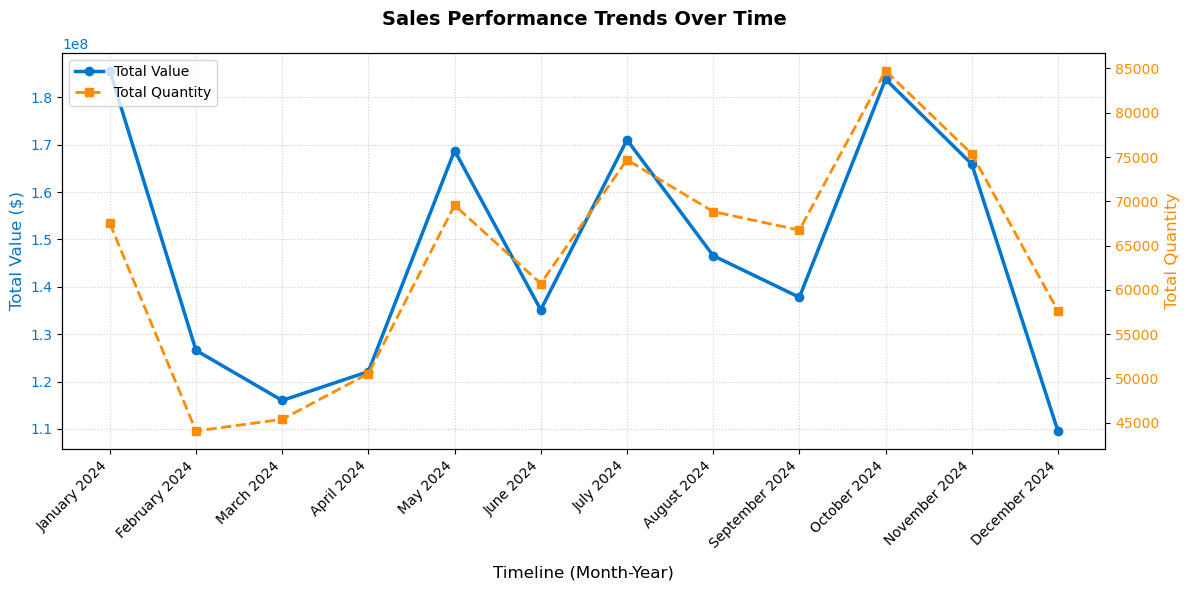

In [27]:
#import matplotlib.pyplot as plt

# Set up the plotting window
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Line 1: Total Value (Left Y-Axis)
color = '#0076CE' # Blue
ax1.set_xlabel('Timeline (Month-Year)', fontsize=12, labelpad=10)
ax1.set_ylabel('Total Value ($)', color=color, fontsize=12)
line1 = ax1.plot(trend_summary['Month-Year'], trend_summary['TOTAL_VALUE'], color=color, marker='o', linewidth=2.5, label='Total Value')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Create a twin axis sharing the same x-axis for Quantity
ax2 = ax1.twinx()

# Plot Line 2: Total Quantity (Right Y-Axis)
color = '#ff8c00' # Dark Orange
ax2.set_ylabel('Total Quantity', color=color, fontsize=12)
line2 = ax2.plot(trend_summary['Month-Year'], trend_summary['QUANTITY'], color=color, marker='s', linewidth=2, linestyle='--', label='Total Quantity')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends from both axes into one clean box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Rotate bottom date labels so they read clearly
fig.autofmt_xdate(rotation=45)

plt.title('Sales Performance Trends Over Time', fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


**Business Classification**

In [67]:
# 1. Aggregate data per unique business
business_segments = df.groupby('ANONYMIZED_BUSINESS').agg(
    TOTAL_QUANTITY=('QUANTITY', 'sum'),
    TOTAL_VALUE=('TOTAL_VALUE', 'sum'),
    FREQUENCY=('TOTAL_VALUE', 'count') # Counts total number of invoice line items/transactions
).reset_index()


In [69]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

# Then import your other libraries
import pandas as pd
import seaborn as sns
# 2. Isolate the numeric columns for clustering
features = ['TOTAL_QUANTITY', 'TOTAL_VALUE', 'FREQUENCY']
X = business_segments[features]

# 3. Standardize features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Run K-Means with exactly 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
business_segments['CLUSTER'] = kmeans.fit_predict(X_scaled)


In [70]:
# 5. Find the average value per cluster to identify which is which
cluster_means = business_segments.groupby('CLUSTER')['TOTAL_VALUE'].mean().sort_values()

# Map the cluster numbers to business labels based on their spending tier
low_cluster = cluster_means.index[0]
med_cluster = cluster_means.index[1]
high_cluster = cluster_means.index[2]

label_map = {low_cluster: 'Low Value', med_cluster: 'Medium Value', high_cluster: 'High Value'}
business_segments['SEGMENT'] = business_segments['CLUSTER'].map(label_map)

# View the structural boundaries of your new groups
print(business_segments.groupby('SEGMENT')[features].mean())


              TOTAL_QUANTITY   TOTAL_VALUE   FREQUENCY
SEGMENT                                               
High Value       4656.923077  1.173407e+07  919.730769
Low Value          70.460367  1.528424e+05   36.797358
Medium Value     1071.538961  2.536669e+06  459.814935


**Forecasting**

In [29]:

# 1. Aggregate your original df down to just Month Start dates and Value
df['DATETIME'] = pd.to_datetime(df['DATE'], format='%B %d, %Y, %I:%M %p')
monthly_data = df.groupby(df['DATETIME'].dt.to_period('M'))['TOTAL_VALUE'].sum().reset_index()

# 2. Convert Period index back to Timestamp and set it as the index
monthly_data['DATETIME'] = monthly_data['DATETIME'].dt.to_timestamp()
monthly_data.set_index('DATETIME', inplace=True)

# 3. Explicitly set the monthly frequency for the statsmodels library
ts_data = monthly_data['TOTAL_VALUE'].asfreq('MS')


In [39]:
from statsmodels.tsa.api import ExponentialSmoothing

# Fit the Holt-Winters Exponential Smoothing Model
# Adjust seasonal_periods=12 for monthly patterns (e.g., annual cycles)
model = ExponentialSmoothing(
    ts_data, 
    trend='add', 
    damped_trend=True,
    seasonal=None 
).fit()

# Forecast the next 3 steps (months) ahead
forecast_steps = 3
forecast_values = model.forecast(steps=forecast_steps)

# Print out your forecasted numeric values cleanly
print("--- 3-Month Sales Value Forecast ---")
print('='*70)
print(forecast_values)


--- 3-Month Sales Value Forecast ---
2025-01-01    1.623373e+08
2025-02-01    1.640667e+08
2025-03-01    1.657787e+08
Freq: MS, dtype: float64


C:\Users\Joe Zawadi\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


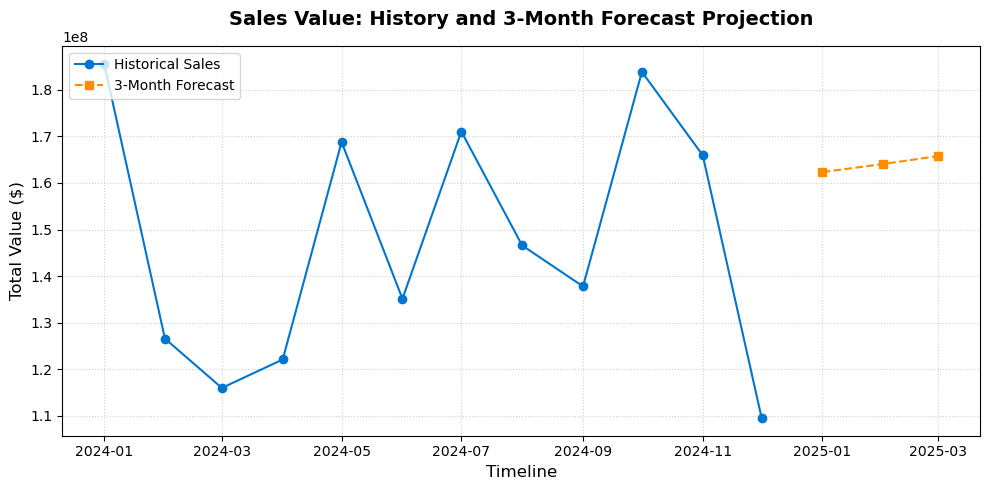

In [40]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot historical actual sales values
plt.plot(ts_data.index, ts_data.values, marker='o', label='Historical Sales', color='#0076CE')

# Plot the 3-month forecast extension
plt.plot(forecast_values.index, forecast_values.values, marker='s', linestyle='--', label='3-Month Forecast', color='#ff8c00')

# Formatting adjustments
plt.title('Sales Value: History and 3-Month Forecast Projection', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Value ($)', fontsize=12)
plt.xlabel('Timeline', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [43]:
df.head(3)

,DATE,ANONYMIZED_CATEGORY,ANONYMIZED_PRODUCT,ANONYMIZED_BUSINESS,ANONYMIZED_LOCATION,QUANTITY,UNIT_PRICE,Month-Year,TOTAL_VALUE,TEMP_DATE,DATETIME
0,"August 18, 2024, 9:32 PM",Category-106,Product-21f4,Business-de42,Location-1ba8,1,850,August 2024,850,2024-08-18 21:32:00,2024-08-18 21:32:00
1,"August 18, 2024, 9:32 PM",Category-120,Product-4156,Business-de42,Location-1ba8,2,1910,August 2024,3820,2024-08-18 21:32:00,2024-08-18 21:32:00
2,"August 18, 2024, 9:32 PM",Category-121,Product-49bd,Business-de42,Location-1ba8,1,3670,August 2024,3670,2024-08-18 21:32:00,2024-08-18 21:32:00


In [71]:
corr_cols=['QUANTITY','TOTAL_VALUE']
print("\n--- Generating Correlation Matrix ---")
print('='*70)
df[corr_cols].corr()




--- Generating Correlation Matrix ---


,QUANTITY,TOTAL_VALUE
QUANTITY,1.000000,0.835333
TOTAL_VALUE,0.835333,1.000000


In [51]:

# 1. Recalculate your sorted monthly trend summary if needed
monthly_trends = df.groupby(['Month-Year', df['TEMP_DATE'].dt.to_period('M')]).agg({
    'QUANTITY': 'sum',
    'TOTAL_VALUE': 'sum'
}).reset_index().sort_values(by='TEMP_DATE')

# 2. Calculate Z-scores for both metrics
monthly_trends['VALUE_Z'] = (monthly_trends['TOTAL_VALUE'] - monthly_trends['TOTAL_VALUE'].mean()) / monthly_trends['TOTAL_VALUE'].std()
monthly_trends['QUANTITY_Z'] = (monthly_trends['QUANTITY'] - monthly_trends['QUANTITY'].mean()) / monthly_trends['QUANTITY'].std()

# 3. Define an anomaly threshold (1.5 standard deviations from the mean)
threshold = 1.5

# 4. Filter the data to isolate anomalies
value_anomalies = monthly_trends[np.abs(monthly_trends['VALUE_Z']) > threshold]
quantity_anomalies = monthly_trends[np.abs(monthly_trends['QUANTITY_Z']) > threshold]

print("--- Value Anomalies Detected ---")
print("="*70)
print(value_anomalies[['Month-Year', 'TOTAL_VALUE', 'VALUE_Z']])

print("\n--- Quantity Anomalies Detected ---")
print("="*70)
print(quantity_anomalies[['Month-Year', 'QUANTITY', 'QUANTITY_Z']])


--- Value Anomalies Detected ---
Empty DataFrame
Columns: [Month-Year, TOTAL_VALUE, VALUE_Z]
Index: []

--- Quantity Anomalies Detected ---
       Month-Year  QUANTITY  QUANTITY_Z
3   February 2024     44063   -1.578014
10   October 2024     84739    1.671509


In [65]:
# Check for unusually high quantities in the anomaly month
anomaly_month_df = df[df['Month-Year'] == 'February 2024']  # Replace with your anomaly month
anomaly_month_df.sort_values(by='QUANTITY', ascending=False).head(5)


,DATE,ANONYMIZED_CATEGORY,ANONYMIZED_PRODUCT,ANONYMIZED_BUSINESS,ANONYMIZED_LOCATION,QUANTITY,UNIT_PRICE,Month-Year,TOTAL_VALUE,TEMP_DATE,DATETIME
137236,"February 15, 2024, 2:27 PM",Category-120,Product-4156,Business-8119,Location-689f,100,2260,February 2024,226000,2024-02-15 14:27:00,2024-02-15 14:27:00
146982,"February 6, 2024, 5:29 PM",Category-75,Product-086d,Business-1e3e,Location-03fc,100,2235,February 2024,223500,2024-02-06 17:29:00,2024-02-06 17:29:00
51526,"February 5, 2024, 8:12 PM",Category-100,Product-68e7,Business-a1a7,Location-0451,90,2060,February 2024,185400,2024-02-05 20:12:00,2024-02-05 20:12:00
89060,"February 9, 2024, 10:51 PM",Category-100,Product-1ff0,Business-b22c,Location-f7fa,70,2115,February 2024,148050,2024-02-09 22:51:00,2024-02-09 22:51:00
185501,"February 15, 2024, 1:38 PM",Category-120,Product-4156,Business-64de,Location-3fc0,70,2260,February 2024,158200,2024-02-15 13:38:00,2024-02-15 13:38:00


In [66]:
# Look at the most frequently ordered items in that month
print(anomaly_month_df.groupby('ANONYMIZED_CATEGORY')['QUANTITY'].sum().sort_values(ascending=False))


ANONYMIZED_CATEGORY
Category-75     11772
Category-120     7870
Category-100     5216
Category-76      4645
Category-77      3742
Category-91      1747
Category-85      1251
Category-119     1190
Category-101      927
Category-84       609
Category-78       559
Category-110      517
Category-111      485
Category-94       461
Category-92       441
Category-106      425
Category-97       369
Category-82       336
Category-107      319
Category-102      307
Category-121      180
Category-95       122
Category-104      103
Category-108       84
Category-96        82
Category-105       81
Category-81        57
Category-113       48
Category-83        46
Category-79        43
Category-109       28
Category-74         1
Name: QUANTITY, dtype: int64
